In [7]:
# =========================================
# CNN FEATURE EXTRACTION
# EFFICIENTNETB3 VERSION
# AI MENU DESCRIPTION + FOOD RECOMMENDATION
# =========================================

import pandas as pd
import numpy as np
import os
import pickle

from tqdm import tqdm

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

from tensorflow.keras.models import Model


# ======================================================
# 1. LOAD DATASET
# ======================================================

df = pd.read_csv(
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/final_refined_food_dataset.csv"
)

print("DATASET SHAPE:")
print(df.shape)


# ======================================================
# 2. FIX IMAGE PATHS FOR KAGGLE
# ======================================================

images_folder = (
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/all_images"
)

df["image_path"] = df["image_path"].apply(
    lambda x: os.path.join(
        images_folder,
        os.path.basename(x)
    )
)


# ======================================================
# 3. LOAD PRETRAINED CNN MODEL
# ======================================================

base_model = EfficientNetB3(

    weights="imagenet",

    include_top=False,

    pooling="avg"
)

model = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

print("\nEFFICIENTNETB3 MODEL LOADED ✅")


# ======================================================
# 4. FEATURE EXTRACTION FUNCTION
# ======================================================

def extract_features(img_path):

    try:

        img = load_img(
            img_path,
            target_size=(300, 300)
        )

        img = img_to_array(img)

        img = np.expand_dims(img, axis=0)

        img = preprocess_input(img)

        features = model.predict(
            img,
            verbose=0
        )

        features = features.flatten()

        return features

    except Exception as e:

        print(f"\nERROR WITH IMAGE:")
        print(img_path)

        return None


# ======================================================
# 5. EXTRACT FEATURES FROM ALL IMAGES
# ======================================================

features_dict = {}

print("\nEXTRACTING FEATURES...\n")

for idx, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    img_path = row["image_path"]

    features = extract_features(img_path)

    if features is not None:

        image_name = os.path.basename(img_path)

        features_dict[image_name] = features


# ======================================================
# 6. SAVE FEATURES
# ======================================================

save_path = "/kaggle/working/featuresB3.pkl"

with open(save_path, "wb") as f:

    pickle.dump(features_dict, f)

print("\nFEATURES SAVED ✅")

print(save_path)


# ======================================================
# 7. SHOW SAMPLE OUTPUT
# ======================================================

sample_key = list(features_dict.keys())[0]

print("\nSAMPLE IMAGE:")
print(sample_key)

print("\nFEATURE VECTOR SHAPE:")
print(features_dict[sample_key].shape)

print("\nFIRST 20 FEATURES:")
print(features_dict[sample_key][:20])


# ======================================================
# 8. TOTAL FEATURES EXTRACTED
# ======================================================

print("\nTOTAL IMAGES PROCESSED:")
print(len(features_dict))

DATASET SHAPE:
(21127, 8)
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

EFFICIENTNETB3 MODEL LOADED ✅

EXTRACTING FEATURES...



 24%|██▍       | 5151/21127 [08:32<24:18, 10.96it/s] /usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 21127/21127 [32:32<00:00, 10.82it/s]



FEATURES SAVED ✅
/kaggle/working/featuresB3.pkl

SAMPLE IMAGE:
img_0.jpg

FEATURE VECTOR SHAPE:
(1536,)

FIRST 20 FEATURES:
[-0.1847   -0.05396  -0.1436   -0.02594   0.2479   -0.01458  -0.003658
 -0.1744   -0.114     0.5605    0.2329   -0.1881   -0.1566   -0.1952
 -0.10815  -0.02715  -0.1637    1.001    -0.01837  -0.1128  ]

TOTAL IMAGES PROCESSED:
21127


In [8]:
# =========================================
# EFFICIENTNETB3 + BIGRU + MULTIHEAD ATTENTION
# AI MENU DESCRIPTION GENERATOR
# =========================================

import pandas as pd
import numpy as np
import pickle
import re
import os
import tensorflow as tf

from tqdm import tqdm

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (

    Input,
    Dense,
    GRU,
    Embedding,
    Dropout,
    Bidirectional,
    BatchNormalization,
    Concatenate,
    GlobalAveragePooling1D,
    MultiHeadAttention,
    LayerNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.utils import Sequence

from sklearn.model_selection import train_test_split


# ======================================================
# MIXED PRECISION
# ======================================================

tf.keras.mixed_precision.set_global_policy(
    'mixed_float16'
)

print("MIXED PRECISION ENABLED ✅")


# ======================================================
# 1. LOAD DATASET
# ======================================================

df = pd.read_csv(
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/final_refined_food_dataset.csv"
)

print("DATASET SHAPE:")
print(df.shape)


# ======================================================
# 2. FIX IMAGE PATHS
# ======================================================

images_folder = (
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/all_images"
)

df["image_path"] = df["image_path"].apply(
    lambda x: os.path.join(
        images_folder,
        os.path.basename(x)
    )
)


# ======================================================
# 3. LOAD CNN FEATURES
# ======================================================

with open(
    "/kaggle/working/featuresB3.pkl",
    "rb"
) as f:

    features = pickle.load(f)

print("\nFEATURES LOADED ✅")

print("TOTAL FEATURES:")
print(len(features))


# ======================================================
# 4. CLEAN TEXT
# ======================================================

def clean_ingredient(text):

    text = str(text).lower()

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^a-zA-Z, ]', '', text)

    return text.strip()


# ======================================================
# 5. CREATE SHORT CAPTIONS
# ======================================================

def create_short_caption(row):

    title = str(row["title"]).lower()

    ingredients = str(row["ingredients"]).split("|")

    ingredients = [
        clean_ingredient(x)
        for x in ingredients
    ]

    ingredients = [
        x for x in ingredients
        if len(x.strip()) > 2
    ]

    ingredients = ingredients[:3]

    ingredients_text = ", ".join(ingredients)

    caption = (
        f"<start> {title} with {ingredients_text} <end>"
    )

    return caption


df["refined_caption"] = df.apply(
    create_short_caption,
    axis=1
)

print("\nCAPTIONS CREATED ✅")


# ======================================================
# 6. TOKENIZER
# ======================================================

captions = df["refined_caption"].tolist()

tokenizer = Tokenizer(
    oov_token="<unk>"
)

tokenizer.fit_on_texts(captions)

vocab_size = len(tokenizer.word_index) + 1

print("\nVOCAB SIZE:")
print(vocab_size)


# ======================================================
# 7. MAX LENGTH
# ======================================================

max_length = 20

print("\nMAX LENGTH:")
print(max_length)


# ======================================================
# 8. TRAIN TEST SPLIT
# ======================================================

train_df, val_df = train_test_split(

    df,

    test_size=0.1,

    random_state=42
)

print("\nTRAIN TEST SPLIT DONE ✅")

print("TRAIN:", train_df.shape)

print("VALID:", val_df.shape)


# ======================================================
# 9. DATA GENERATOR
# ======================================================

class DataGenerator(Sequence):

    def __init__(
        self,
        dataframe,
        features,
        tokenizer,
        max_length,
        batch_size=32,
        shuffle=True
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.features = features

        self.tokenizer = tokenizer

        self.max_length = max_length

        self.batch_size = batch_size

        self.shuffle = shuffle

        self.indexes = np.arange(len(self.dataframe))

        self.on_epoch_end()

    def __len__(self):

        return int(
            np.floor(len(self.dataframe) / self.batch_size)
        )

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):

        batch_indexes = self.indexes[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        X1 = []
        X2 = []
        y = []

        for idx in batch_indexes:

            row = self.dataframe.iloc[idx]

            image_name = row["image_path"].split("/")[-1]

            if image_name not in self.features:
                continue

            image_features = self.features[image_name]

            caption = row["refined_caption"]

            seq = self.tokenizer.texts_to_sequences(
                [caption]
            )[0]

            for i in range(1, len(seq)):

                in_seq = seq[:i]

                out_seq = seq[i]

                in_seq = pad_sequences(
                    [in_seq],
                    maxlen=self.max_length
                )[0]

                X1.append(image_features)

                X2.append(in_seq)

                y.append(out_seq)

        return (

            (
                np.array(X1, dtype=np.float32),

                np.array(X2, dtype=np.int32)
            ),

            np.array(y, dtype=np.int32)
        )


# ======================================================
# 10. CREATE GENERATORS
# ======================================================

train_generator = DataGenerator(

    train_df,

    features,

    tokenizer,

    max_length,

    batch_size=32
)

val_generator = DataGenerator(

    val_df,

    features,

    tokenizer,

    max_length,

    batch_size=32,

    shuffle=False
)

print("\nDATA GENERATORS READY ✅")


# ======================================================
# 11. IMAGE FEATURE BRANCH
# ======================================================

inputs1 = Input(shape=(1536,))

fe1 = Dropout(0.5)(inputs1)

fe2 = Dense(
    512,
    activation='relu'
)(fe1)

fe2 = BatchNormalization()(fe2)

fe2 = Dropout(0.4)(fe2)


# ======================================================
# 12. TEXT BRANCH
# ======================================================

inputs2 = Input(shape=(max_length,))

se1 = Embedding(

    vocab_size,

    256,

    mask_zero=False

)(inputs2)

se2 = Dropout(0.4)(se1)

# First BiGRU
se3 = Bidirectional(

    GRU(
        256,
        return_sequences=True
    )

)(se2)

# Second BiGRU
se4 = Bidirectional(

    GRU(
        256,
        return_sequences=True
    )

)(se3)

# MultiHead Attention
attention = MultiHeadAttention(

    num_heads=4,

    key_dim=64

)(se4, se4)

# Residual Connection
attention = attention + se4

attention = LayerNormalization()(attention)

# Pooling
se5 = GlobalAveragePooling1D()(attention)

se5 = Dropout(0.4)(se5)


# ======================================================
# 13. MERGE BRANCHES
# ======================================================

decoder1 = Concatenate()([fe2, se5])

decoder2 = Dense(
    512,
    activation='relu'
)(decoder1)

decoder2 = BatchNormalization()(decoder2)

decoder2 = Dropout(0.5)(decoder2)

outputs = Dense(

    vocab_size,

    activation='softmax',

    dtype='float32'

)(decoder2)


# ======================================================
# 14. BUILD MODEL
# ======================================================

model = Model(

    inputs=[inputs1, inputs2],

    outputs=outputs
)

optimizer = Adam(
    learning_rate=0.0003
)

loss_function = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(

    loss=loss_function,

    optimizer=optimizer,

    metrics=['accuracy']
)

print("\nMODEL SUMMARY:\n")

model.summary()


# ======================================================
# 15. CALLBACKS
# ======================================================

checkpoint = ModelCheckpoint(

    "/kaggle/working/best_model.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=4,

    restore_best_weights=True
)


# ======================================================
# 16. TRAIN MODEL
# ======================================================

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=50,

    callbacks=[
        checkpoint,
        early_stop
    ]
)


# ======================================================
# 17. SAVE TOKENIZER
# ======================================================

with open(
    "/kaggle/working/tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(tokenizer, f)

print("\nTOKENIZER SAVED ✅")


# ======================================================
# 18. SAVE MODEL
# ======================================================

model.save(
    "/kaggle/working/final_model.keras"
)

print("\nMODEL SAVED ✅")


# ======================================================
# 19. FINAL INFO
# ======================================================

print("\nTRAINING COMPLETE 🔥")

print("\nFILES SAVED:")

print("/kaggle/working/final_model.keras")

print("/kaggle/working/tokenizer.pkl")

print("/kaggle/working/featuresB3.pkl")

MIXED PRECISION ENABLED ✅
DATASET SHAPE:
(21127, 8)

FEATURES LOADED ✅
TOTAL FEATURES:
21127

CAPTIONS CREATED ✅

VOCAB SIZE:
11617

MAX LENGTH:
20

TRAIN TEST SPLIT DONE ✅
TRAIN: (19014, 8)
VALID: (2113, 8)

DATA GENERATORS READY ✅

MODEL SUMMARY:



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 20, 256)   │  2,973,952 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 20, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 20, 512)   │    789,504 │ dropout_7[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 20, 512)   │  1,182,720 │ bidirectional_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 1536)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 512)   │    525,568 │ bidirectional_3[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1536)      │          0 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 512)   │          0 │ multi_head_atten… │
│                     │                   │            │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    786,944 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 512)   │      1,024 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 512)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1024)      │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    524,800 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 512)       │          0 │ batch_normalizat

 Total params: 12,748,129 (48.63 MB)

 Trainable params: 12,746,081 (48.62 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.0610 - loss: 7.5681
Epoch 1: val_loss improved from inf to 5.00838, saving model to /kaggle/working/best_model.keras
594/594 ━━━━━━━━━━━━━━━━━━━━ 125s 198ms/step - accuracy: 0.0611 - loss: 7.5663 - val_accuracy: 0.1701 - val_loss: 5.0084
Epoch 2/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.1801 - loss: 4.9368
Epoch 2: val_loss improved from 5.00838 to 4.38288, saving model to /kaggle/working/best_model.keras
594/594 ━━━━━━━━━━━━━━━━━━━━ 117s 197ms/step - accuracy: 0.1801 - loss: 4.9366 - val_accuracy: 0.2368 - val_loss: 4.3829
Epoch 3/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.2303 - loss: 4.4043
Epoch 3: val_loss improved from 4.38288 to 4.05096, saving model to /kaggle/working/best_model.keras
594/594 ━━━━━━━━━━━━━━━━━━━━ 117s 197ms/step - accuracy: 0.2303 - loss: 4.4042 - val_accuracy: 0.2752 - val_loss: 4.0510
Epoch 4/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.2595 - loss: 4.12

MODEL LOADED ✅
TOKENIZER LOADED ✅
FEATURES LOADED ✅
DATASET LOADED ✅
EFFICIENTNETB3 LOADED ✅
FEATURES EXTRACTED ✅


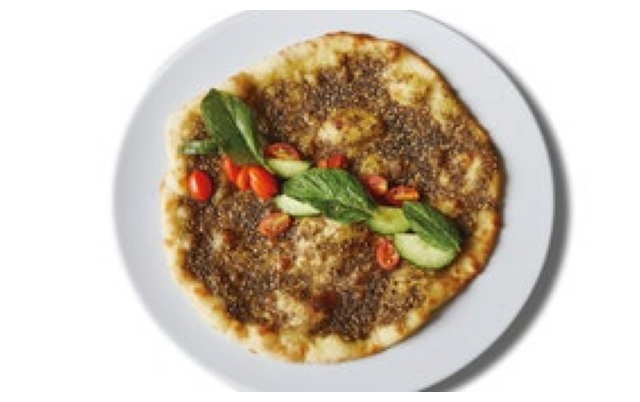

AI MENU DESCRIPTION 🔥

Man'oushe with crispy almonds with unsalted butter softened sugar cornstarch.

RECOMMENDED DISHES 🔥

1. Man'oushe with Za'atar Oil, Tomatoes, and Cucumber
2. Chicken-Fried Steak
3. Slow-cooker beef goulash
4. Hanger Steak with Charred Scallion Sauce
5. Spicy Pork Bowls with Greens


In [10]:
# =========================================
# EFFICIENTNETB3 + BIGRU + MULTIHEAD ATTENTION
# FOOD IMAGE CAPTION GENERATION
# + FOOD RECOMMENDATION SYSTEM
# FINAL VERSION
# =========================================

import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from PIL import Image

from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing.sequence import (
    pad_sequences
)

from tensorflow.keras.applications import (
    EfficientNetB3
)

from tensorflow.keras.applications.efficientnet import (
    preprocess_input
)

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

from sklearn.metrics.pairwise import (
    cosine_similarity
)


# ======================================================
# 1. LOAD MODEL
# ======================================================

model = load_model(
    "/kaggle/working/final_model.keras"
)

print("MODEL LOADED ✅")


# ======================================================
# 2. LOAD TOKENIZER
# ======================================================

with open(
    "/kaggle/working/tokenizer.pkl",
    "rb"
) as f:

    tokenizer = pickle.load(f)

print("TOKENIZER LOADED ✅")


# ======================================================
# 3. LOAD FEATURES
# ======================================================

with open(
    "/kaggle/working/featuresB3.pkl",
    "rb"
) as f:

    features = pickle.load(f)

print("FEATURES LOADED ✅")


# ======================================================
# 4. LOAD DATASET
# ======================================================

df = pd.read_csv(
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/final_refined_food_dataset.csv"
)

print("DATASET LOADED ✅")


# ======================================================
# 5. FIX IMAGE PATHS
# ======================================================

images_folder = (
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/all_images"
)

df["image_path"] = df["image_path"].apply(
    lambda x: images_folder + "/" + x.split("/")[-1]
)


# ======================================================
# 6. MAX LENGTH
# ======================================================

max_length = 20


# ======================================================
# 7. EFFICIENTNETB3 MODEL
# ======================================================

cnn_model = EfficientNetB3(

    weights='imagenet',

    include_top=False,

    pooling='avg'
)

print("EFFICIENTNETB3 LOADED ✅")


# ======================================================
# 8. IMAGE FEATURE EXTRACTION
# ======================================================

def extract_features(img_path):

    img = load_img(
        img_path,
        target_size=(300, 300)
    )

    img = img_to_array(img)

    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img)

    features = cnn_model.predict(
        img,
        verbose=0
    )

    return features.flatten()


# ======================================================
# 9. INDEX -> WORD
# ======================================================

index_to_word = {

    index: word

    for word, index in tokenizer.word_index.items()
}


def idx_to_word(integer):

    return index_to_word.get(integer)


# ======================================================
# 10. GENERATE CAPTION
# ======================================================

def generate_caption(
    model,
    tokenizer,
    photo,
    max_length
):

    in_text = "<start>"

    used_words = []

    for i in range(max_length):

        sequence = tokenizer.texts_to_sequences(
            [in_text]
        )[0]

        sequence = pad_sequences(
            [sequence],
            maxlen=max_length
        )

        yhat = model.predict(
            [
                photo.reshape(1, 1536),
                sequence
            ],
            verbose=0
        )

        yhat_probs = yhat[0]

        # temperature sampling
        temperature = 0.7

        yhat_probs = np.log(
            yhat_probs + 1e-10
        ) / temperature

        exp_preds = np.exp(yhat_probs)

        yhat_probs = (
            exp_preds / np.sum(exp_preds)
        )

        # top-k filtering
        top_k = 5

        top_indices = np.argsort(
            yhat_probs
        )[-top_k:]

        top_probs = yhat_probs[top_indices]

        top_probs = (
            top_probs / np.sum(top_probs)
        )

        yhat = np.random.choice(
            top_indices,
            p=top_probs
        )

        word = idx_to_word(yhat)

        if word is None:
            break

        # stop repetition
        if used_words.count(word) >= 2:
            break

        used_words.append(word)

        in_text += ' ' + word

        if word == '<end>':
            break

    return in_text


# ======================================================
# 11. CLEAN CAPTION
# ======================================================

def clean_caption(caption):

    caption = caption.replace(
        '<start>',
        ''
    )

    caption = caption.replace(
        '<end>',
        ''
    )

    caption = caption.lower()

    words = caption.split()

    cleaned_words = []

    stop_words = {

        "tablespoon",
        "tablespoons",
        "teaspoon",
        "teaspoons",
        "cup",
        "cups",
        "divided",
        "chopped",
        "sliced",
        "finely",
        "freshly"
    }

    for word in words:

        if word in stop_words:
            continue

        if len(cleaned_words) > 0:

            if word == cleaned_words[-1]:
                continue

        cleaned_words.append(word)

    final_words = []

    word_counts = {}

    for word in cleaned_words:

        if word not in word_counts:
            word_counts[word] = 0

        if word_counts[word] < 2:

            final_words.append(word)

            word_counts[word] += 1

    final_words = final_words[:18]

    caption = " ".join(final_words)

    caption = caption.capitalize()

    if not caption.endswith("."):
        caption += "."

    return caption


# ======================================================
# 12. RECOMMEND SIMILAR DISHES
# ======================================================

def recommend_dishes(
    query_features,
    features_dict,
    top_n=5
):

    image_names = list(
        features_dict.keys()
    )

    feature_vectors = np.array(
        list(features_dict.values())
    )

    similarities = cosine_similarity(
        [query_features],
        feature_vectors
    )[0]

    top_indices = similarities.argsort(
    )[-top_n:][::-1]

    recommendations = []

    used_titles = set()

    for idx in top_indices:

        image_name = image_names[idx]

        matched_row = df[
            df['image_path'].str.contains(
                image_name
            )
        ]

        if len(matched_row) > 0:

            title = matched_row.iloc[0][
                'title'
            ]

            if title not in used_titles:

                recommendations.append(title)

                used_titles.add(title)

    return recommendations


# ======================================================
# 13. TEST IMAGE
# ======================================================

test_image = (
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/all_images/img_10019.jpg"
)


# ======================================================
# 14. EXTRACT FEATURES
# ======================================================

query_features = extract_features(
    test_image
)

print("FEATURES EXTRACTED ✅")


# ======================================================
# 15. GENERATE CAPTION
# ======================================================

raw_caption = generate_caption(

    model,

    tokenizer,

    query_features,

    max_length
)

caption = clean_caption(
    raw_caption
)


# ======================================================
# 16. RECOMMENDATIONS
# ======================================================

recommendations = recommend_dishes(

    query_features,

    features,

    top_n=5
)


# ======================================================
# 17. DISPLAY RESULTS
# ======================================================

img = Image.open(test_image)

plt.figure(figsize=(8, 8))

plt.imshow(img)

plt.axis('off')

plt.show()


print("=" * 60)

print("AI MENU DESCRIPTION 🔥\n")

print(caption)

print("\n" + "=" * 60)

print("RECOMMENDED DISHES 🔥\n")

for i, rec in enumerate(
    recommendations,
    1
):

    print(f"{i}. {rec}")